<a href="https://colab.research.google.com/github/mirahdyana123-cloud/tugas_clustering_052771625/blob/main/Tugas1_MirahDyana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap 1: Load Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [7]:
df = pd.read_csv('dataset.csv')
df

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022/02/25,21.0
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021/04/14,20.0
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020/01/11,NaN
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022/01/29,22.0


Tahap 2: Eksplorasi Awal (EDA)

In [8]:
print("\nInfo Dataset:")
print(df.info())


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB
None


In [9]:
# Jumlah nilai hilang perkolom
print("\nJumlah Missing Values:")
print(df.isnull().sum())


Jumlah Missing Values:
ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64


In [10]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(df.describe(include='all'))


Statistik Deskriptif:
           ID Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
count      99   99            99               99     99          70   
unique     99   10             2                4      4           5   
top     MH001  Eka     Laki-laki  Teknik Komputer   Cuti           C   
freq        1   15            50               28     29          17   
mean      NaN  NaN           NaN              NaN    NaN         NaN   
std       NaN  NaN           NaN              NaN    NaN         NaN   
min       NaN  NaN           NaN              NaN    NaN         NaN   
25%       NaN  NaN           NaN              NaN    NaN         NaN   
50%       NaN  NaN           NaN              NaN    NaN         NaN   
75%       NaN  NaN           NaN              NaN    NaN         NaN   
max       NaN  NaN           NaN              NaN    NaN         NaN   

       Tanggal_Ujian       Umur  
count             99  90.000000  
unique            97        NaN  
top       

Tahap 3: Menangani Missing Values

In [11]:
# mengecek jumlah nilai kosong sebelum imputasi
print("Missing Values Sebelum Imputasi:")
print(df[['Nilai_Akhir', 'Umur']].isnull().sum())

Missing Values Sebelum Imputasi:
Nilai_Akhir    29
Umur            9
dtype: int64


In [13]:
# Imputasi kolom Umur
# Menggunakan mean karena data numerik
# ------------------------------------------
df['Umur'] = df['Umur'].fillna(df['Umur'].mean())

In [14]:
# Imputasi kolom Nilai_Akhir Menggunakan modus
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])

In [15]:
# Cek jumlah nilai kosong setelah imputasi
print("\nMissing Values Setelah Imputasi:")
print(df[['Nilai_Akhir', 'Umur']].isnull().sum())


Missing Values Setelah Imputasi:
Nilai_Akhir    0
Umur           0
dtype: int64


Tahap 4: Normalisasi Format Tanggal

In [16]:
# tipe data sebelum konversi
print("Tipe Data Sebelum Konversi:")
print(df['Tanggal_Ujian'].dtype)

Tipe Data Sebelum Konversi:
object


In [17]:
# Konversi kolom Tanggal_Ujian ke format datetime
df['Tanggal_Ujian'] = pd.to_datetime(df['Tanggal_Ujian'], errors='coerce')

/tmp/ipykernel_7766/1381587408.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Tanggal_Ujian'] = pd.to_datetime(df['Tanggal_Ujian'], errors='coerce')


In [18]:
# Cek tipe data setelah konversi
print("\nTipe Data Setelah Konversi:")
print(df['Tanggal_Ujian'].dtype)


Tipe Data Setelah Konversi:
datetime64[ns]


In [19]:
# Mencoba menampilkan 5 data tanggal pertama
print("\nContoh Data Tanggal_Ujian:")
print(df['Tanggal_Ujian'].head())


Contoh Data Tanggal_Ujian:
0   2020-04-13
1          NaT
2          NaT
3          NaT
4          NaT
Name: Tanggal_Ujian, dtype: datetime64[ns]


Tahap 5: Encoding Label

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
# Membuat objek LabelEncoder
le = LabelEncoder()

In [22]:
# Daftar kolom kategorikal
kolom_kategori = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']

In [23]:
# Menampilkan data sebelum encoding
print("Data Sebelum Encoding:")
print(df[kolom_kategori].head())

Data Sebelum Encoding:
   Nama Jenis_Kelamin            Prodi Status Nilai_Akhir
0  Iwan     Laki-laki  Teknik Komputer  Aktif           C
1   Eka     Perempuan  Teknik Komputer  Lulus           E
2  Iwan     Laki-laki  Teknik Komputer  Aktif           C
3   Eka     Perempuan  Teknik Komputer  Aktif           D
4  Joko     Perempuan     Data Science  Aktif           C


In [24]:
# Proses encoding setiap kolom
for col in kolom_kategori:
    df[col] = le.fit_transform(df[col])

In [25]:
# data setelah encoding
print("\nData Setelah Encoding:")
print(df[kolom_kategori].head())


Data Setelah Encoding:
   Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir
0     8              0      3       0            2
1     4              1      3       3            4
2     8              0      3       0            2
3     4              1      3       0            3
4     9              1      0       0            2


In [26]:
# Menampilkan tipe data terbaru
print("\nTipe Data Setelah Encoding:")
print(df[kolom_kategori].dtypes)


Tipe Data Setelah Encoding:
Nama             int64
Jenis_Kelamin    int64
Prodi            int64
Status           int64
Nilai_Akhir      int64
dtype: object


Tahap 6: Split Data

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# Menentukan fitur (X) dan target (y)
# Target yang diprediksi: Status
X = df.drop('Status', axis=1)
y = df['Status']

In [29]:
# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
# Menampilkan ukuran data hasil split
print("Ukuran Data Setelah Split:")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

Ukuran Data Setelah Split:
X_train : (79, 7)
X_test  : (20, 7)
y_train : (79,)
y_test  : (20,)


In [31]:
# Menampilkan beberapa data train
print("\nContoh Data Latih:")
print(X_train.head())


Contoh Data Latih:
       ID  Nama  Jenis_Kelamin  Prodi  Nilai_Akhir Tanggal_Ujian  Umur
49  MH050     4              1      1            2           NaT  21.0
70  MH071     5              0      1            2    2021-08-15  19.0
68  MH069     7              1      1            1           NaT  24.0
15  MH016     4              0      2            4           NaT  19.0
39  MH040     2              0      1            2           NaT  29.0


Tahap 7: Visualisasi

In [32]:
import matplotlib.pyplot as plt

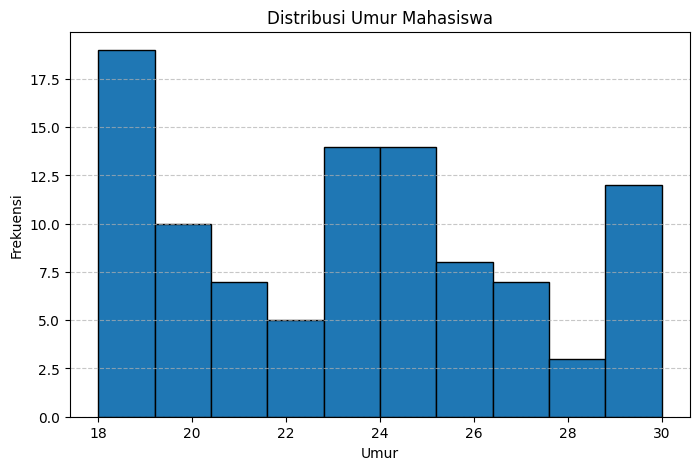

In [33]:
# Histogram Kolom Umur
plt.figure(figsize=(8,5))
plt.hist(df['Umur'], bins=10, edgecolor='black')

plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


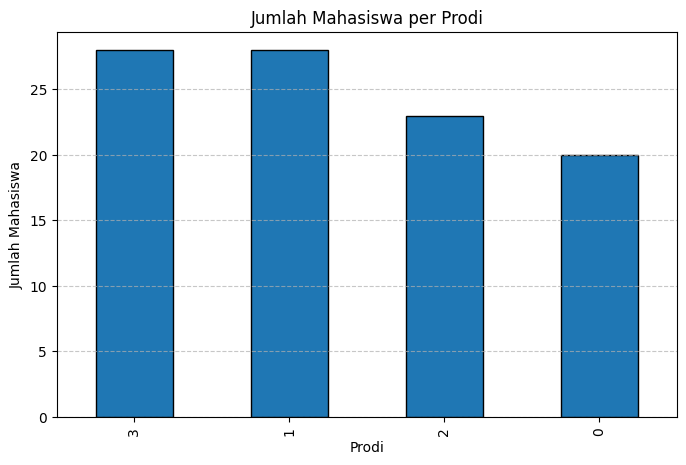

In [34]:
# Grafik Batang Jumlah Mahasiswa per Prodi
plt.figure(figsize=(8,5))
df['Prodi'].value_counts().plot(kind='bar', edgecolor='black')

plt.title('Jumlah Mahasiswa per Prodi')
plt.xlabel('Prodi')
plt.ylabel('Jumlah Mahasiswa')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()